# Importing the library

In [2]:
!pip install xgboost


In [3]:

pip install scikit-learn imbalanced-learn --upgrade

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib

# Pre required Steps

In [2]:

df = pd.read_csv("new_cleaned_cardio_data.csv")
target = "cardio"

In [3]:
X = df.drop(columns=['id', 'cardio', 'age', 'height'])
y = df['cardio']

In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)


In [5]:

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

joblib.dump(scaler, "standard_scaler.joblib")

['standard_scaler.joblib']

# Smote balance

In [6]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)
x_train_res,y_train_res = smote.fit_resample(x_train_scaled,y_train)
print(f"Original training shape: {x_train_scaled.shape}")
print(f"SMOTE training shape: {X_train_smote.shape}")

Original training shape: (56251, 14)
SMOTE training shape: (56936, 14)


# MODELS

# -> Decision Tree

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

dt_pred = dt.predict(x_test_scaled)
mse = mean_squared_error(y_test, dt_pred)


print("Decision Tree Model Performance:")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("MSE:", mse)

Decision Tree Model Performance:
Accuracy: 0.6168613021916494
MSE: 0.38313869780835064


# -> Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train_smote, y_train_smote)
lr_pred_raw = lr.predict(x_test_scaled)
lr_pred = [1 if val >= 0.5 else 0 for val in lr_pred_raw]

mse = mean_squared_error(y_test, lr_pred)

print("Linear Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("MSE:", mse)

Linear Regression Model Performance:
Accuracy: 0.7198848184290514
MSE: 0.28011518157094867


# -> Logistic Regression

In [9]:
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(x_train_res,y_train_res)

logref_pred = logreg.predict(x_test_scaled)

mse = mean_squared_error(y_test, logref_pred)

print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, logref_pred))
print("MSE:", mse)

Logistic Regression Model Performance:
Accuracy: 0.7194048952167653
MSE: 0.2805951047832347


# -> Random Forest

In [10]:

rf = RandomForestClassifier(n_estimators=300,max_depth=12,min_samples_split=4, random_state=42)
rf.fit(x_train_res, y_train_res)

rf_pred = rf.predict(x_test_scaled)

mse = mean_squared_error(y_test, rf_pred)

print("Random Forest Model Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("MSE:", mse)

Random Forest Model Performance:
Accuracy: 0.7277235642297233
MSE: 0.27227643577027677


# -> XGBoost

In [11]:

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss"
)

xgb.fit(x_train_res, y_train_res)

xgb_pred = xgb.predict(x_test_scaled)
acc_xgb = accuracy_score(y_test, xgb_pred)

mse = mean_squared_error(y_test, xgb_pred)


print("XGBoost Model Performance:")
print("Accuracy:", acc_xgb)
print("MSE:", mse)

XGBoost Model Performance:
Accuracy: 0.725323948168293
MSE: 0.2746760518317069


# -> KNN

In [12]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train_res, y_train_res)

knn_pred = knn.predict(x_test_scaled)

mse = mean_squared_error(y_test, knn_pred)

print("KNN Model Performance:")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("MSE:", mse)

KNN Model Performance:
Accuracy: 0.7120460726283795
MSE: 0.28795392737162057


# -> SVM

In [ ]:
svc = SVC(kernel='rbf', random_state=42)
svc.fit(x_train_res, y_train_res)

svc_pred = svc.predict(x_test_scaled)

mse = mean_squared_error(y_test, svc_pred)

print("SVM Model Performance:")
print("Accuracy:", accuracy_score(y_test, svc_pred))
print("MSE:", mse)

# -> CAT Boost


In [42]:
pip install catboost


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
catboost = CatBoostClassifier(
    iterations=300,        
    depth=8,               
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="Logloss",
    random_seed=42,
    verbose=0                
)


catboost.fit(
    x_train_res,
    y_train_res
)


catboost_pred = catboost.predict(x_test_scaled)

acc_catboost = accuracy_score(y_test, catboost_pred)
mse = mean_squared_error(y_test, catboost_pred)

print("CatBoost Model Performance:")
print("Accuracy:", acc_catboost)
print("MSE:", mse)

CatBoost Model Performance:
Accuracy: 0.7283634618461047
MSE: 0.2716365381538954


# -> Catboost hyperparameter tuning(GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [7]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0,
)

param_grid = {
    'iterations': [200, 300],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6]
}

grid_result = cat_model.grid_search(
    param_grid,
    X=X_train_smote,
    y=y_train_smote,
    cv=3,
    plot=False
)



bestTest = 0.7316473481
bestIteration = 120

0:	loss: 0.7316473	best: 0.7316473 (0)	total: 4.07s	remaining: 28.5s

bestTest = 0.7327010889
bestIteration = 197

1:	loss: 0.7327011	best: 0.7327011 (1)	total: 13.2s	remaining: 39.5s

bestTest = 0.7320864067
bestIteration = 298

2:	loss: 0.7320864	best: 0.7327011 (1)	total: 19.2s	remaining: 32s

bestTest = 0.733315771
bestIteration = 215

3:	loss: 0.7333158	best: 0.7333158 (3)	total: 27.6s	remaining: 27.6s

bestTest = 0.7313839129
bestIteration = 172

4:	loss: 0.7313839	best: 0.7333158 (3)	total: 34.1s	remaining: 20.5s

bestTest = 0.7326132771
bestIteration = 153

5:	loss: 0.7326133	best: 0.7333158 (3)	total: 38.2s	remaining: 12.7s

bestTest = 0.731998595
bestIteration = 278

6:	loss: 0.7319986	best: 0.7333158 (3)	total: 44.1s	remaining: 6.3s

bestTest = 0.7326132771
bestIteration = 153

7:	loss: 0.7326133	best: 0.7333158 (3)	total: 50.3s	remaining: 0us
Estimating final quality...
Training on fold [0/3]

bestTest = 0.7294520548
bestIterati

In [8]:
cat_model.fit(X_train_smote, y_train_smote)


In [9]:
best_catboost = cat_model


In [10]:
y_pred = best_catboost.predict(x_test)


In [11]:
from sklearn.metrics import accuracy_score
print("Tuned CatBoost Accuracy:", accuracy_score(y_test, y_pred))


Tuned CatBoost Accuracy: 0.48664213725803873


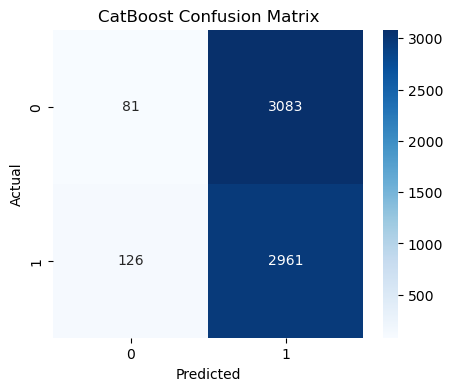

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix")
plt.show()


In [34]:
print("Best Parameters:")
print(grid_result['params'])


Best Parameters:
{'depth': 4, 'learning_rate': 0.1, 'iterations': 300}


In [36]:
best_accuracy = max(grid_result['cv_results']['test-Accuracy-mean'])
print("Best CV Accuracy:", best_accuracy)


Best CV Accuracy: 0.7307328160612497


In [48]:
grid_search.fit(X_train_smote, y_train_smote)

best_catboost = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

AttributeError: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

# Export joblib file

In [51]:
joblib.dump(logreg, "models/logistic_regression_model.joblib")
joblib.dump(rf, "models/random_forest_model.joblib")
joblib.dump(dt, "models/decision_tree_model.joblib")
joblib.dump(xgb, "models/XGBClassifier_model.joblib")
joblib.dump(knn, "models/knn_model.joblib")
joblib.dump(svc, "models/svc_model.joblib")
joblib.dump(catboost,"models/CATBoostClassifier_model.joblib")

print("New models (KNN & SVM) have been saved successfully.")
print("Models have been trained and saved successfully.")



New models (KNN & SVM) have been saved successfully.
Models have been trained and saved successfully.


In [ ]:
import json

# Collect all model metrics
model_metrics = {
    "Logistic Regression": accuracy_score(y_test, logref_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "CatBoost": accuracy_score(y_test, catboost_pred)
}


In [ ]:
cm = confusion_matrix(y_test, catboost_pred)
tn, fp, fn, tp = cm.ravel()

fpr, tpr, _ = roc_curve(y_test, catboost_probs)
roc_auc = auc(fpr, tpr)

indices = np.linspace(0, len(fpr) - 1, 20).astype(int)
roc_data = [{"x": float(fpr[i]), "y": float(tpr[i])} for i in indices]

precision = precision_score(y_test, catboost_pred)
recall = recall_score(y_test, catboost_pred)
f1 = f1_score(y_test, catboost_pred)

feature_names = x.columns.tolist()
importances = catboost.feature_importances_
feature_importance_data = [
    {"name": name, "value": float(imp)} 
    for name, imp in zip(feature_names, importances)
]
feature_importance_data.sort(key=lambda x: x["value"], reverse=True)

metrics = {
    "Logistic Regression": accuracy_score(y_test, logref_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": acc_xgb,
    "CatBoost": acc_catboost
}

detailed_metrics = {
    "accuracy": float(acc_catboost),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "confusion_matrix": {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    },
    "roc_curve": roc_data,
    "feature_importance": feature_importance_data,
    "model_comparison": metrics
}


with open("detailed_metrics.json", "w") as f:
    json.dump(detailed_metrics, f, indent=2)
    
# Save to JSON file
with open("model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=2)

print("Model metrics saved to model_metrics.json")
print(json.dumps(model_metrics, indent=2))